In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from utils import *

with open(obs_labels_path, "rb") as f:
    obs_data_dict = pickle.load(f)

with open(attack_labels_path, "rb") as f:
    beh_data_dict = pickle.load(f)

setup_plot_style()

In [2]:
mouse_id_list = list(obs_data_dict.keys())[: -1] # get rid of the familiar vs novel first

mouse_pred_dict_full = {}
for idx, mouse_id in enumerate(mouse_id_list):
    pred_d_s_pd = obs_data_dict[mouse_id]
    mouse_pred_dict = {}
    for day_idx in np.arange(1, 9):
        for session_idx in np.arange(1, 4):
            pred_d_s = pred_d_s_pd[(pred_d_s_pd["day_id"] == day_idx) & (pred_d_s_pd["session_id"] == session_idx)]
            if len(pred_d_s) == 0:
                print(f"No data for {mouse_id} day {day_idx} session {session_idx}")
                continue
            pred_smpl = label_to_categories(pred_d_s["prediction"].values)
            smoothed_pred_d_s_categories = rolling_mode_fast(pred_smpl)
            concat_pred = np.stack([pred_d_s["prediction"].values, pred_smpl, smoothed_pred_d_s_categories])
            mouse_pred_dict[f"d{day_idx}_s{session_idx}"] = concat_pred
    mouse_pred_dict_full[mouse_id] = mouse_pred_dict

In [4]:
obs_mouse_id_list = [k for k, v in label_to_cond_dict.items() if v == "obs"]

mtx_len_dict = {}
day_sesh_labels = []
day_sesh_labels_other = []

for idx, mouse_id in enumerate(obs_mouse_id_list):
    pred_full = obs_data_dict[mouse_id]
    pred_full['attack_labels'] = 0
    
    # Calculate matrix length for this mouse and build day_sesh_labels once
    pred_d_s_list = []
    for d_idx in np.arange(1, 9):
        for s_idx in np.arange(1, 4):
            pred_d_s = pred_full[(pred_full["day_id"] == d_idx) & (pred_full["session_id"] == s_idx)]
            pred_d_s_list.append(pred_d_s)
            if idx == 0:  # Only add labels once for the first mouse
                day_sesh_labels.append(f"D{d_idx}, S{s_idx}")
                day_sesh_labels_other.append(f"d{d_idx}_s{s_idx}")
                
    sesh_lengths = [len(pred) for pred in pred_d_s_list if len(pred) > 15000]
    if sesh_lengths:
        min_len = np.min(sesh_lengths)  
        mean_len = np.mean(sesh_lengths).astype(int)
        max_len = np.max(sesh_lengths)
        mtx_len_dict[mouse_id] = max_len
        print(mouse_id, min_len, mean_len, max_len, len(sesh_lengths) / 24)
    
    # Add attack labels to predictions
    for d_idx in np.arange(1, 9):
        for s_idx in np.arange(1, 4):
            pred_d_s_arr = mouse_pred_dict_full[mouse_id][f"d{d_idx}_s{s_idx}"]
            attack_labels_d_s = beh_data_dict[f'{mouse_id}_d{d_idx}_obs_t{s_idx}']['attack labels']
            diff = pred_d_s_arr.shape[1] - attack_labels_d_s.shape[0]
            if diff < 0:
                print(f"{mouse_id}, Day {d_idx}, Session {s_idx}, skipped due to missing predictions")
            else:
                attack_labels_d_s_padded = np.concatenate([np.zeros(diff, dtype=attack_labels_d_s.dtype), attack_labels_d_s])
                mouse_pred_dict_full[mouse_id][f"d{d_idx}_s{s_idx}"] = np.concatenate([pred_d_s_arr, attack_labels_d_s_padded.reshape(1, -1)], axis = 0).astype(int)

1185 18928 22377 25023 1.0
30R2 18981 23252 28100 0.9166666666666666
30R2, Day 2, Session 1, skipped due to missing predictions
30R2, Day 4, Session 1, skipped due to missing predictions
30R2, Day 8, Session 1, skipped due to missing predictions
29L 22140 22851 24320 1.0
1162B 21371 23458 31889 1.0
87L2 19580 22896 24763 0.9583333333333334
87L2, Day 8, Session 1, skipped due to missing predictions
933R 17981 23336 25979 1.0
933R, Day 4, Session 2, skipped due to missing predictions
933R, Day 5, Session 2, skipped due to missing predictions
86L 21501 22929 27461 1.0
86L, Day 3, Session 1, skipped due to missing predictions
927R 21382 23857 27326 1.0
927L 22124 23492 25463 1.0


In [5]:
## To make sure I have all the data, for all animals, make a matrix to fit the longest session, and just fill in 0 (since I am already switching to simple categories)
fps = 40
sesh_start_idx = fps * 60 ## trim the first 1 min
attack_beh_prop_mice_list = []
beh_prop_mice_list = []

before_onset_prop, onset_prop, offset_prop, after_offset_prop = .25, .25, .25, .25

for mice_id in obs_mouse_id_list:
    mtx_len = mtx_len_dict[mice_id]
    pred_d_s_list = mouse_pred_dict_full[mice_id]
    attack_start_stop_indices = {}

    all_pred_smpl = []
    for idx, pred_d_s in enumerate(pred_d_s_list.values()):
        attack_labels = pred_d_s[-1, sesh_start_idx: ]
        pred_smpl = pred_d_s[1, sesh_start_idx: ]
        all_pred_smpl.append(pred_smpl)
        attack_start_stop_indices[day_sesh_labels_other[idx]] = find_continuous_ones(attack_labels)
    
    # Calculate overall behavioral proportions across all sessions
    all_pred_combined = np.concatenate(all_pred_smpl)
    overall_beh_prop = np.zeros(4)
    for beh_idx in np.arange(4):
        overall_beh_prop[beh_idx] = np.sum(all_pred_combined == beh_idx + 1) / len(all_pred_combined)
    beh_prop_mice_list.append(overall_beh_prop)

    # Create 5 segments: -25-0%, 0-25%, 25-75%, 75-100%, 100-125%
    seg_1_beh, seg_2_beh, seg_3_beh, seg_4_beh, seg_5_beh = [], [], [], [], []

    for idx, (sesh_label, attack_indices) in enumerate(attack_start_stop_indices.items()):
        for attack_bout_idx in attack_indices:
            onset_idx = attack_bout_idx[0]
            offset_idx = attack_bout_idx[1]
            seg_len = offset_idx - onset_idx

            # Calculate segment boundaries
            seg_1_start = onset_idx - (seg_len * before_onset_prop).astype(int)  # -25%
            seg_1_end = onset_idx  # 0%
            seg_2_start = onset_idx  # 0%
            seg_2_end = onset_idx + (seg_len * onset_prop).astype(int)  # 25%
            seg_3_start = seg_2_end  # 25%
            seg_3_end = offset_idx - (seg_len * offset_prop).astype(int)  # 75%
            seg_4_start = seg_3_end  # 75%
            seg_4_end = offset_idx  # 100%
            seg_5_start = offset_idx  # 100%
            seg_5_end = offset_idx + (seg_len * after_offset_prop).astype(int)  # 125%

            # Extract segments if they are valid
            if seg_1_start >= 0 and seg_1_start != seg_1_end:
                seg_1_beh.append(all_pred_smpl[idx][seg_1_start:seg_1_end])
            if seg_2_start != seg_2_end:
                seg_2_beh.append(all_pred_smpl[idx][seg_2_start:seg_2_end])
            if seg_3_start != seg_3_end:
                seg_3_beh.append(all_pred_smpl[idx][seg_3_start:seg_3_end])
            if seg_4_start != seg_4_end:
                seg_4_beh.append(all_pred_smpl[idx][seg_4_start:seg_4_end])
            if seg_5_end < mtx_len and seg_5_start != seg_5_end:
                seg_5_beh.append(all_pred_smpl[idx][seg_5_start:seg_5_end])

    # Concatenate all segments
    seg_1_beh = np.concatenate(seg_1_beh) if seg_1_beh else np.array([])
    seg_2_beh = np.concatenate(seg_2_beh) if seg_2_beh else np.array([])
    seg_3_beh = np.concatenate(seg_3_beh) if seg_3_beh else np.array([])
    seg_4_beh = np.concatenate(seg_4_beh) if seg_4_beh else np.array([])
    seg_5_beh = np.concatenate(seg_5_beh) if seg_5_beh else np.array([])

    # Calculate proportions for each segment
    attack_beh_prop = np.zeros((5, 4))
    for beh_idx in np.arange(4):
        if len(seg_1_beh) > 0:
            attack_beh_prop[0, beh_idx] = np.sum(seg_1_beh == beh_idx + 1) / len(seg_1_beh)
        if len(seg_2_beh) > 0:
            attack_beh_prop[1, beh_idx] = np.sum(seg_2_beh == beh_idx + 1) / len(seg_2_beh)
        if len(seg_3_beh) > 0:
            attack_beh_prop[2, beh_idx] = np.sum(seg_3_beh == beh_idx + 1) / len(seg_3_beh)
        if len(seg_4_beh) > 0:
            attack_beh_prop[3, beh_idx] = np.sum(seg_4_beh == beh_idx + 1) / len(seg_4_beh)
        if len(seg_5_beh) > 0:
            attack_beh_prop[4, beh_idx] = np.sum(seg_5_beh == beh_idx + 1) / len(seg_5_beh)

    attack_beh_prop_mice_list.append(attack_beh_prop)
    
attack_beh_prop_mice_list = np.stack(attack_beh_prop_mice_list)
beh_prop_mice_list = np.stack(beh_prop_mice_list)

In [ ]:
# ABOUTME: Multiple comparisons correction using Bonferroni method
# ABOUTME: Corrects p-values for 20 comparisons (5 periods × 4 behaviors)

n_mice = len(obs_mouse_id_list)
n_segments = 5
n_behaviors = 4

behavior_names = ['Behavior 1', 'Behavior 2', 'Behavior 3', 'Behavior 4']
segment_names = ['Before onset (-25-0%)', 'Early onset (0-25%)', 'Mid attack (25-75%)', 
                 'Late offset (75-100%)', 'After offset (100-125%)']

from statsmodels.stats.multitest import multipletests

# Extract all p-values
all_p_values = []
test_labels = []

for beh_idx in range(n_behaviors):
    baseline_proportions = beh_prop_mice_list[:, beh_idx]
    
    for seg_idx in range(n_segments):
        segment_proportions = attack_beh_prop_mice_list[:, seg_idx, beh_idx]
        _, p_value = stats.ttest_rel(segment_proportions, baseline_proportions)
        all_p_values.append(p_value)
        test_labels.append(f"{behavior_names[beh_idx]} - {segment_names[seg_idx]}")

# Apply Bonferroni correction
reject_bonf, pvals_bonf, _, _ = multipletests(all_p_values, alpha=0.05, method='bonferroni')

# Also calculate FDR (False Discovery Rate) correction
reject_fdr, pvals_fdr, _, _ = multipletests(all_p_values, alpha=0.05, method='fdr_bh')

# Create corrected results table
corrected_results = []
for i, (label, p_orig, p_bonf, p_fdr, rej_bonf, rej_fdr) in enumerate(
    zip(test_labels, all_p_values, pvals_bonf, pvals_fdr, reject_bonf, reject_fdr)):
    
    # Determine significance for each method
    if p_orig < 0.001:
        sig_orig = '***'
    elif p_orig < 0.01:
        sig_orig = '**'
    elif p_orig < 0.05:
        sig_orig = '*'
    else:
        sig_orig = 'ns'
    
    sig_bonf = 'Yes' if rej_bonf else 'No'
    sig_fdr = 'Yes' if rej_fdr else 'No'
    
    corrected_results.append({
        'Test': label,
        'p (uncorrected)': f'{p_orig:.4f}',
        'Uncorr. Sig.': sig_orig,
        'p (Bonferroni)': f'{p_bonf:.4f}',
        'Bonf. Sig.': sig_bonf,
        'p (FDR)': f'{p_fdr:.4f}',
        'FDR Sig.': sig_fdr
    })

corrected_df = pd.DataFrame(corrected_results)

print("\nMultiple Comparisons Correction Results")
print("=" * 120)
print(corrected_df.to_string(index=False))
print("=" * 120)
print(f"\nTotal number of tests: {len(all_p_values)}")
print(f"Bonferroni correction threshold: p < {0.05/len(all_p_values):.5f}")
print(f"Number of significant tests (uncorrected): {sum(1 for p in all_p_values if p < 0.05)}")
print(f"Number of significant tests (Bonferroni): {sum(reject_bonf)}")
print(f"Number of significant tests (FDR): {sum(reject_fdr)}")

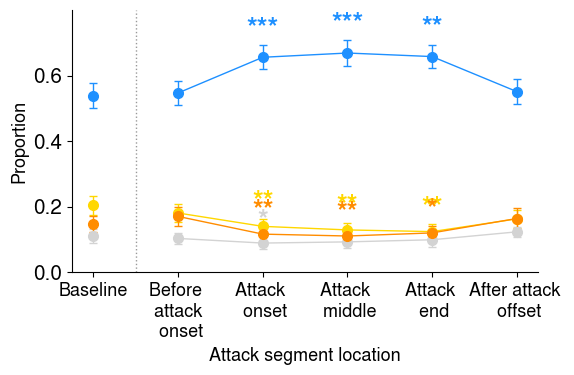

In [ ]:
# Use the attack behavior proportion data directly
combined_data = attack_beh_prop_mice_list  # shape: (n_mice, 5, 4)
colors = ["dodgerblue", "gold", "lightgray", "darkorange"]

fontsize = 14
n_mice, n_segments, n_categories = combined_data.shape

segment_labels = ["Before \n attack \n onset", "Attack \n onset", "Attack \n middle", "Attack \n end", "After attack \n offset"]

# Calculate means and standard errors for attack segments
attack_means = np.mean(combined_data, axis=0)  # shape: (5, 4)
attack_sems = np.std(combined_data, axis=0) / np.sqrt(n_mice)  # shape: (5, 4)

# Calculate means and standard errors for baseline
baseline_data = beh_prop_mice_list  # shape: (n_mice, 4)
baseline_means = np.mean(baseline_data, axis=0)  # shape: (4,)
baseline_sems = np.std(baseline_data, axis=0) / np.sqrt(n_mice)  # shape: (4,)

# Use FDR-corrected p-values from earlier analysis
# Reshape pvals_fdr from the previous cell into (n_segments, n_categories)
p_values_corrected = np.array(pvals_fdr).reshape(n_behaviors, n_segments).T  # Transpose to get (n_segments, n_categories)

def get_significance_marker(p_value):
    """Convert p-value to significance marker"""
    if p_value < 0.001:
        return '***'
    elif p_value < 0.01:
        return '**'
    elif p_value < 0.05:
        return '*'
    else:
        return ''

# Create x-axis positions
x_positions = np.arange(n_segments)

fig, ax = plt.subplots(figsize=(6, 4))
baseline_pos = -1
fontsize = 13

for cat_idx in range(n_categories):
    # Plot attack segment data with error bars
    ax.errorbar(x_positions, attack_means[:, cat_idx], 
                yerr=attack_sems[:, cat_idx],
                color=colors[cat_idx], marker='o', markersize=7,
                capsize=3, capthick=1, linewidth=1, elinewidth=1,
                label=categories_label_dict[cat_idx + 1])
    
    # Add significance markers next to each point using FDR-corrected p-values
    for seg_idx in range(n_segments):
        sig_marker = get_significance_marker(p_values_corrected[seg_idx, cat_idx])
        if sig_marker:
            y_pos = attack_means[seg_idx, cat_idx] + attack_sems[seg_idx, cat_idx] + .01
            ax.text(x_positions[seg_idx], y_pos, sig_marker, 
                   color=colors[cat_idx], fontsize=20, fontweight='bold',
                   ha='center', va='bottom')
    
    # Add baseline point on x-axis for comparison
    ax.errorbar(baseline_pos, baseline_means[cat_idx], 
                yerr=baseline_sems[cat_idx], 
                color=colors[cat_idx], marker='o', markersize=7,
                capsize=3, capthick=1, linewidth=1, elinewidth=1)

# Add vertical line to separate baseline from attack segments
ax.axvline(x=-0.5, color='gray', linestyle='dotted', alpha=0.8, lw = 1)

ax.set_ylabel("Proportion", fontsize=fontsize)
ax.set_xlabel("Attack segment location", fontsize=fontsize)
ax.set_xticks(np.concatenate([[baseline_pos], x_positions]),  ["Baseline"] + segment_labels, fontsize = fontsize)
ax.tick_params(axis='x', labelsize=fontsize)
ax.tick_params(axis='y', labelsize=fontsize)
ax.set_yticks(np.arange(0, .8, 0.2), np.round(np.arange(0, .8, 0.2), 2), fontsize = fontsize + 2)
ax.set_ylim(0, .8)

plt.tight_layout()
sns.despine()

plt.savefig(os.path.join(fig_pub_path, "behavioral_categories_attack_proportion_by_segment.svg"), format="svg")
plt.show()